# cable Workflow

推荐入口 notebook：选择一个主配置 JSON，运行该 config 声明的全部模板，并完成 config 级 summary 与模板级 case 钻取。


In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
from IPython.display import display

# 向上遍历文件系统，定位包含 braincell 和 examples 目录的项目根目录
def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")


def drop_external_module(module_name, expected_root):
    loaded = sys.modules.get(module_name)
    loaded_file = getattr(loaded, "__file__", None)
    if loaded_file is None or Path(loaded_file).resolve().is_relative_to(expected_root):
        return
    for name in list(sys.modules):
        if name == module_name or name.startswith(f"{module_name}."):
            del sys.modules[name]


REPO_ROOT = find_repo_root()
CABLE_ROOT = REPO_ROOT / "examples" / "neuron_compare" / "cable"
WORKFLOWS_ROOT = CABLE_ROOT / "workflows"

# 优先导入当前仓库源码，避免 Jupyter kernel 复用环境中其他 checkout
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(WORKFLOWS_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKFLOWS_ROOT))

drop_external_module("braincell", REPO_ROOT)
drop_external_module("workflow_api", WORKFLOWS_ROOT)

import workflow_api
import braincell
if not Path(braincell.__file__).resolve().is_relative_to(REPO_ROOT):
    raise RuntimeError(f"Imported braincell from unexpected path: {braincell.__file__}")
if not Path(workflow_api.__file__).resolve().is_relative_to(WORKFLOWS_ROOT):
    raise RuntimeError(f"Imported workflow_api from unexpected path: {workflow_api.__file__}")

import brainstate
brainstate.environ.set(precision=64)

## Parameters

这里只手动设置主配置路径和是否生成图。模板列表由 config 自己声明。


In [2]:
config_path = CABLE_ROOT / "configs" / "BC.json"
plot_cases = True


## Input Preview

In [3]:
inputs = workflow_api.load_config_workflow_inputs(config_path)
print("config_path:", inputs["config_path"])
print("config_name:", inputs["config_name"])
print("template_names:", inputs["template_names"])
print("n_templates:", inputs["n_templates"])
print("default_out_dir:", inputs["default_out_dir"])


config_path: /home/swl/braincell-ion_dyn/examples/neuron_compare/cable/configs/BC.json
config_name: BC
template_names: ('ac', 'dc', 'vinit', 'cv')
n_templates: 4
default_out_dir: /home/swl/braincell-ion_dyn/examples/neuron_compare/cable/results/config_runs/BC


## Run Workflow

In [4]:
run_info = workflow_api.run_notebook_config_workflow(
    config_path=config_path,
    out_dir=None,
    plot=plot_cases,
    expand_only=False,
    raise_on_failure=False,
)

print("status:", run_info["status"])
print("config_name:", run_info["config_name"])
print("out_dir:", run_info["out_dir"])
print("n_templates:", run_info["n_templates"])
print(json.dumps(run_info["status_counts"], indent=2, ensure_ascii=False))

template_run = next(
    (row for row in run_info["template_runs"] if row["batch_status"] in {"ok", "partial"}),
    None,
)
if template_run is None:
    raise RuntimeError("No successful template run; check failures.csv in the output directory.")

template_out_dir = Path(template_run["out_dir"])
tables = workflow_api.build_summary_tables(template_out_dir)
print("template_name:", template_run["template_name"])
print("template_out_dir:", template_out_dir)


--No graphics will be displayed.
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [124]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [107]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [17]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(



6633 lines read

/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/BC/morphology/BC.asc problems


Main branch starting at line 168 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 3401 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 4942 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 5437 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 6075 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 6282 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

Main branch starting at line 6332 is outside the soma bounding boxes
  Making a logical connection to center of nearest soma

66

,observable,n_rows,n_cases,mae_mean,rmse_mean,max_abs_max,rel_mae_pct_mean
0,voltage_sum,9,9,5.526300e-06,6.740999e-06,2.830827e-05,2.515496e-08
1,voltage_midpoint_mean,9,9,8.072482e-08,1.063463e-07,5.826956e-07,1.259878e-07


,case_id,group_id,observable,mae,rmse,max_abs,rel_mae_pct
0,ac__008,ac,voltage_sum,1.607211e-05,1.880357e-05,2.830827e-05,7.375687e-08
1,ac__007,ac,voltage_sum,1.036865e-05,1.323090e-05,2.721580e-05,4.720861e-08
2,ac__005,ac,voltage_sum,8.035456e-06,9.401099e-06,1.415301e-05,3.650766e-08
3,ac__004,ac,voltage_sum,5.183727e-06,6.614772e-06,1.360672e-05,2.345924e-08
4,ac__006,ac,voltage_sum,2.818873e-06,3.656288e-06,7.829902e-06,1.272154e-08
5,ac__002,ac,voltage_sum,3.213459e-06,3.759610e-06,5.659826e-06,1.451287e-08
6,ac__001,ac,voltage_sum,2.072770e-06,2.645096e-06,5.441274e-06,9.346615e-09
7,ac__003,ac,voltage_sum,1.408839e-06,1.827473e-06,3.913774e-06,6.347797e-09
8,ac__000,ac,voltage_sum,5.628154e-07,7.301795e-07,1.564073e-06,2.533418e-09
9,ac__008,ac,voltage_midpoint_mean,2.483087e-07,3.191253e-07,5.826956e-07,3.912520e-07


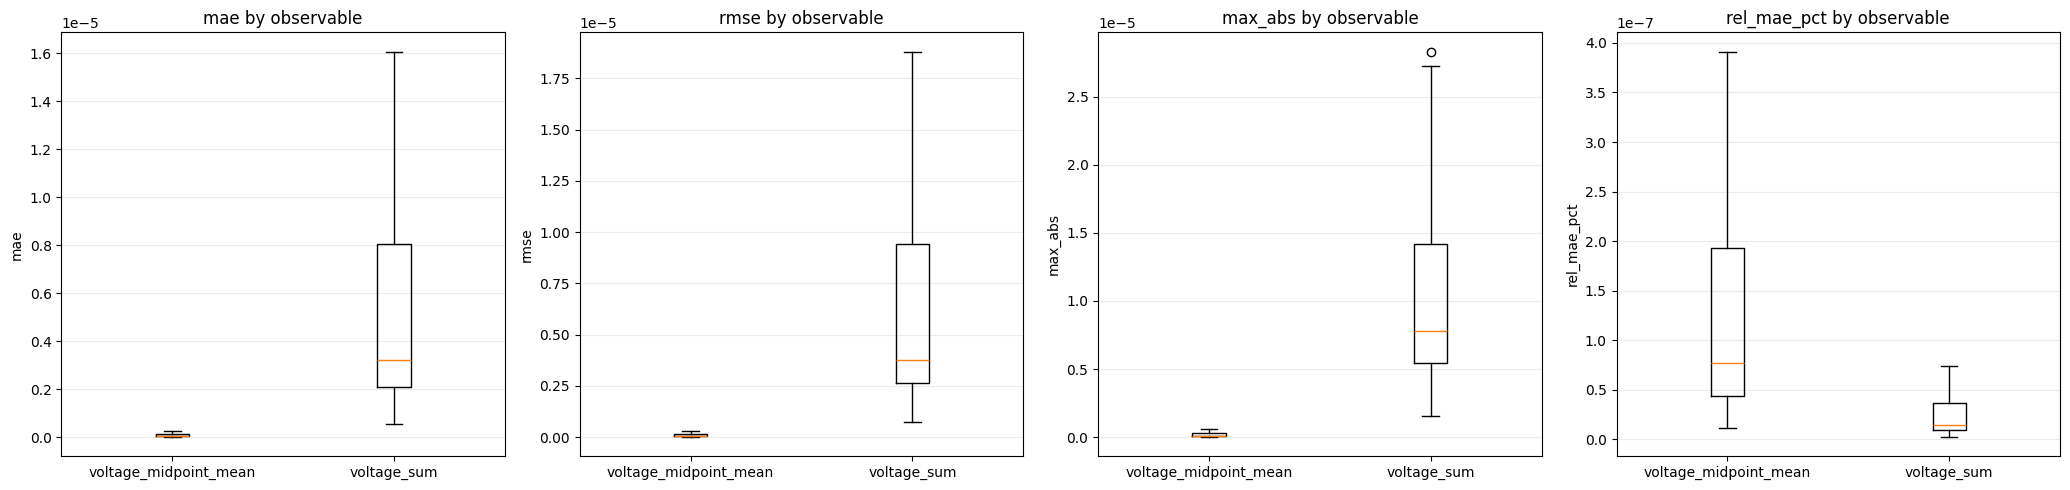

In [5]:
display(tables["by_observable_df"])

worst_columns = ["case_id", "group_id", "observable", "mae", "rmse", "max_abs", "rel_mae_pct"]
display(tables["worst_cases_df"][worst_columns].head(10))

if not tables["failed_df"].empty:
    display(tables["failed_df"][["case_id", "group_id", "error_message"]].drop_duplicates())

workflow_api.plot_observable_metric_boxplots(tables)
plt.show()


worst_case_id: ac__008


,compartment_index,mae,max_abs,rel_mae_pct,rmse,braincell_label,neuron_label,braincell_canonical_name,neuron_canonical_name
0,341,1.252399e-06,0.000002,0.000002,1.460749e-06,dend[41]:cv2,dend[41]:seg2,dend[41],dend[41]
1,340,1.206233e-06,0.000002,0.000002,1.383277e-06,dend[41]:cv1,dend[41]:seg1,dend[41],dend[41]
2,339,1.186630e-06,0.000002,0.000002,1.316143e-06,dend[41]:cv0,dend[41]:seg0,dend[41],dend[41]
3,148,7.665503e-07,0.000001,0.000001,9.426727e-07,axon[48]:cv1,axon[48]:seg1,axon[48],axon[48]
4,149,7.381274e-07,0.000002,0.000001,9.264947e-07,axon[48]:cv2,axon[48]:seg2,axon[48],axon[48]
5,5,7.330327e-07,0.000001,0.000001,8.404908e-07,axon[0]:cv2,axon[0]:seg2,axon[0],axon[0]
6,150,6.967357e-07,0.000002,0.000001,8.843076e-07,axon[49]:cv0,axon[49]:seg0,axon[49],axon[49]
7,151,6.953887e-07,0.000002,0.000001,8.834618e-07,axon[49]:cv1,axon[49]:seg1,axon[49],axon[49]
8,152,6.940605e-07,0.000002,0.000001,8.824136e-07,axon[49]:cv2,axon[49]:seg2,axon[49],axon[49]
9,153,6.928041e-07,0.000001,0.000001,8.798685e-07,axon[50]:cv0,axon[50]:seg0,axon[50],axon[50]


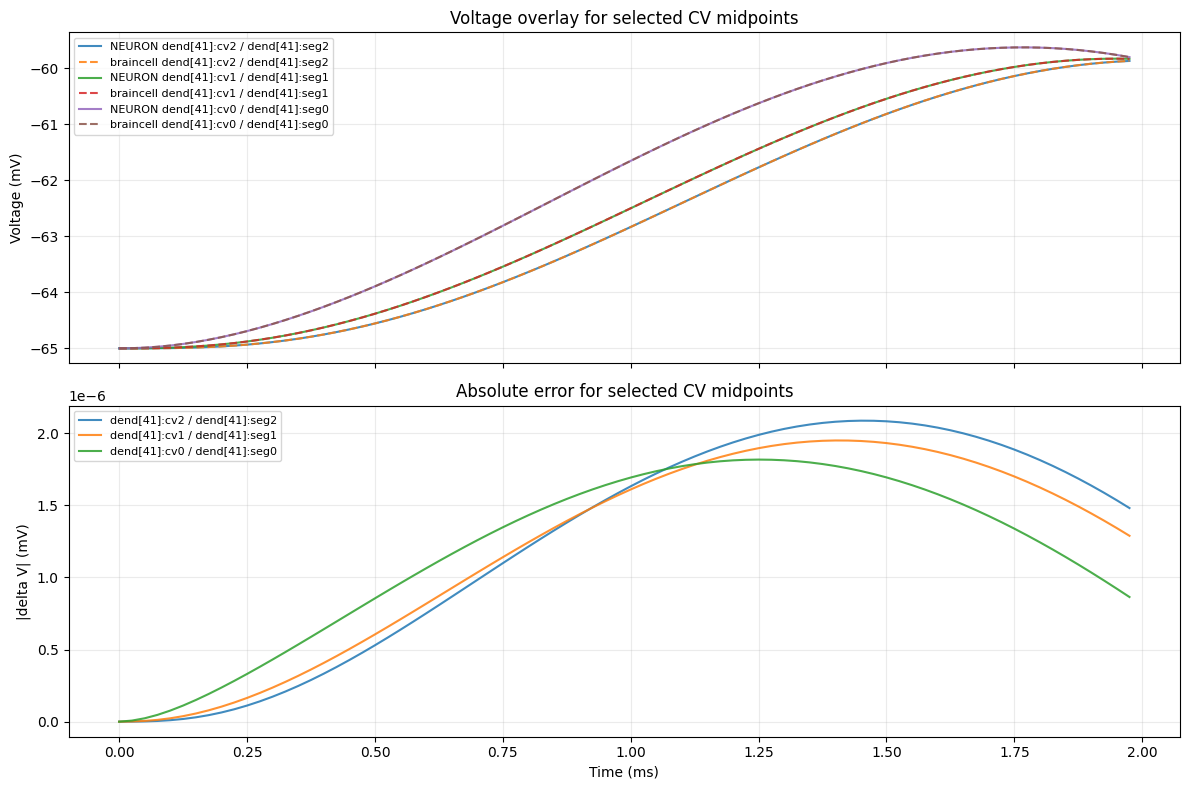

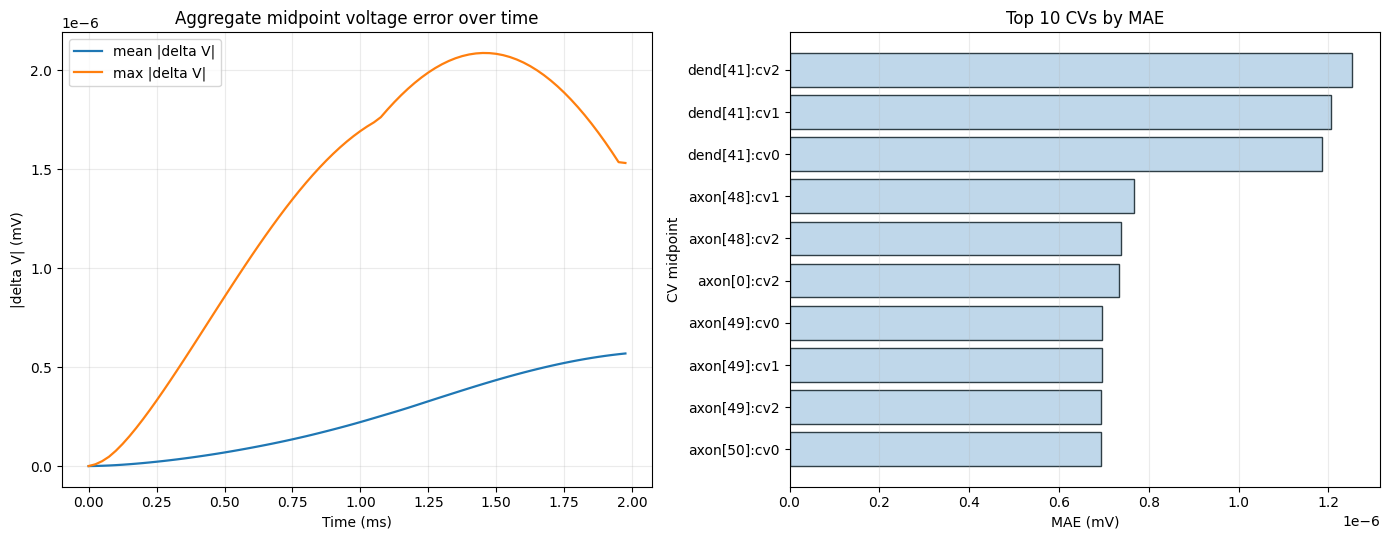

In [6]:
worst_case_id = tables["worst_cases_df"].iloc[0]["case_id"]
print("worst_case_id:", worst_case_id)

case_result = workflow_api.load_case_result(template_out_dir, worst_case_id)
case_metrics_df = workflow_api.build_case_metric_table(case_result)
display(case_metrics_df.head(10))

workflow_api.plot_case_overlay(case_result, max_compartments=3)
plt.show()

workflow_api.plot_case_error_summary(case_result, top_k=10)
plt.show()
